In [3]:
import os
import numpy as np
import cv2    # opencv-python to be installed
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
# from torchsummary import summary
from tqdm import tqdm

In [4]:
# Data Path
data_path = r'C:\Users\hp\Desktop\Early Disease Prediction\Data'

In [5]:
# Defining the class name 
class_name = ['acne','eczema','pigmentation']

# Creating a function to  get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    files_list = os.listdir(dir_name)
    return files_list
files_list_acne_train = get_list_of_files(data_path+'/train/'+class_name[0])
files_list_eczema_train = get_list_of_files(data_path+'/train/'+class_name[1])
files_list_pigmentation_train = get_list_of_files(data_path+'/train/'+class_name[2])
files_list_acne_test = get_list_of_files(data_path+'/test/'+class_name[0])
files_list_eczema_test = get_list_of_files(data_path+'/test/'+class_name[1])
files_list_pigmentation_test = get_list_of_files(data_path+'/test/'+class_name[2])

In [6]:
print("Number of train samples in acne category {}".format(len(files_list_acne_train)))
print("Number of train samples in eczema category {}".format(len(files_list_eczema_train)))
print("Number of train samples in pigmentation category {}".format(len(files_list_pigmentation_train)))
print("Number of test samples in acne category {}".format(len(files_list_acne_test)))
print("Number of test samples in eczema category {}".format(len(files_list_eczema_test)))
print("Number of test samples in pigmentation category {}".format(len(files_list_pigmentation_test)))

Number of train samples in acne category 840
Number of train samples in eczema category 1235
Number of train samples in pigmentation category 568
Number of test samples in acne category 312
Number of test samples in eczema category 309
Number of test samples in pigmentation category 143


### Exploring the images 
To check hamara image kesa dikhta h 

(480, 720, 3)


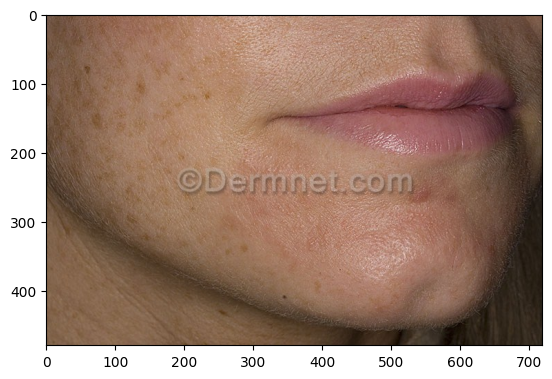

In [7]:
rand_img_no = np.random.randint(0,len(files_list_acne_train))
img = data_path + '/train/acne/'+ files_list_acne_train[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(472, 720, 3)


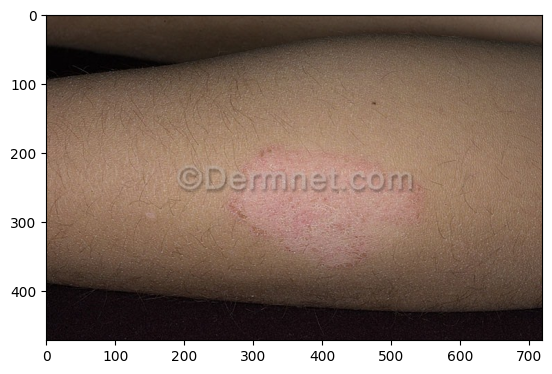

In [8]:
img = data_path + '/train/eczema/'+ files_list_eczema_train[np.random.randint(0,len(files_list_eczema_train))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(720, 480, 3)


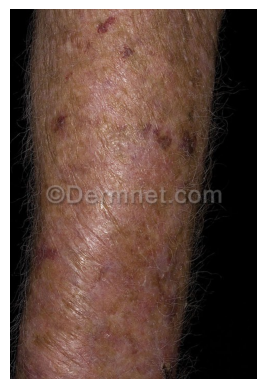

In [9]:
img = data_path + '/train/pigmentation/'+ files_list_pigmentation_train[np.random.randint(0,len(files_list_pigmentation_train))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.axis("off")
plt.show()

## jesa ki we can say ki hamara 3 classes ki aur sbki random size h input shape fix nhi h  train ki now we need to make it fix 
taki hamara model khiin pr bias na hojaye

(720, 482, 3)


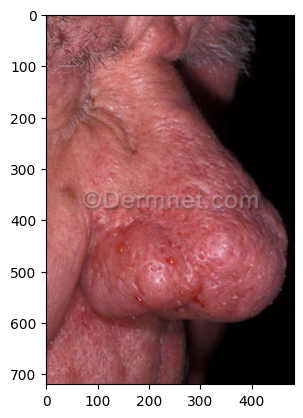

In [10]:
rand_img_no = np.random.randint(0,len(files_list_acne_test))
img = data_path + '/test/acne/'+ files_list_acne_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(472, 720, 3)


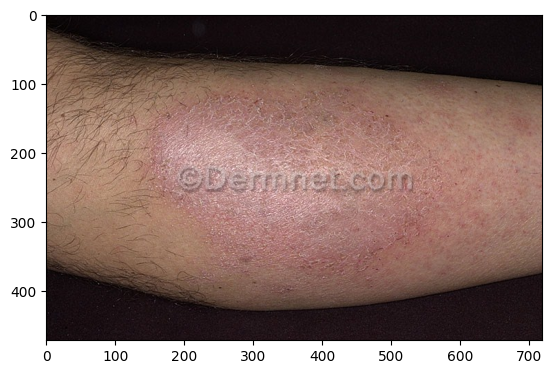

In [11]:
rand_img_no = np.random.randint(0,len(files_list_eczema_test))
img = data_path + '/test/eczema/'+ files_list_eczema_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(640, 720, 3)


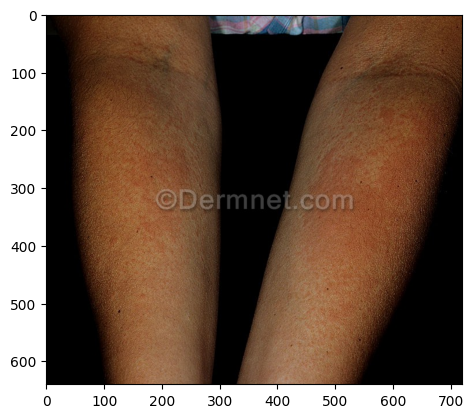

In [12]:
rand_img_no = np.random.randint(0,len(files_list_pigmentation_test))
img = data_path + '/test/pigmentation/'+ files_list_pigmentation_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

## hamara test mein bhi shape differnt h 

### Transforming the Images 

- Now that we have seen the sample of the images let's transform the data now 
- We need to perform transformation on both train and test images 
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.

In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

In [13]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Random zoom
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Skin images kisi bhi taraf ho sakti hain
    transforms.RandomRotation(20), # Rotation badha diya
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Lighting handle karne ke liye
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


In [14]:
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 32, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 32, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

['acne', 'eczema', 'pigmentation']
Number of train images: 2643
Number of test images: 764


## kuki hum custom model nhi le skte hmein trainig mein bhut wqt lgega
## isilie we will transfer learning 3 classes ke lie EFFICIENTBO ka use krke 

In [15]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [16]:
import torchvision.models as models

model = models.efficientnet_b0(weights='DEFAULT')

## bekar model accha perform nhi kiya
# for param in model.parameters():
#     param.requires_grad = False

# num_inputs = model.classifier[1].in_features

# model.classifier = nn.Sequential(
#     nn.Dropout(p=0.3, inplace=True), # Overfitting se bachne ke liye
#     nn.Linear(num_inputs, 3)         # 3 classes setup
# )

# # 4. Model ko GPU/CPU par bhejna
# model = model.to(device)


for param in model.parameters():
    param.requires_grad = True

# Classifier wahi rahega
num_inputs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True), # Dropout badha kar 0.5 kar diya
    nn.Linear(num_inputs, 3)
)
print(f"EfficientNet-B0 loaded on {device} with 3 output classes.")

EfficientNet-B0 loaded on cpu with 3 output classes.


In [17]:
# Train images ke counts: [Acne, Eczema, Pigmentation]
# Pehle calculated weights: [1.04, 0.71, 1.55]

# Hum Pigmentation (index 2) ko thoda aur push karenge recall badhane ke liye
# Acne: 1.2, Eczema: 0.8, Pigmentation: 2.0 (Ya jo aap suggest kar rahe ho)
manual_weights = [1.2, 0.8, 2.2] 
weights_tensor = torch.FloatTensor(manual_weights).to(device)

print(f"Applying Manual Weights: {manual_weights}")
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Applying Manual Weights: [1.2, 0.8, 2.2]


In [18]:
import torch.optim as optim
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# Scheduler: Ye learning rate ko tab kam karega jab loss ghatna band ho jaye
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

### kuki hum healthcare domain mein hain to hmein recall bhut zruri h bhut important param h 
## islie hmein recall ko reduce krnahoga

In [19]:
from sklearn.metrics import recall_score

def calculate_metrics(outputs, targets):
    _, preds = torch.max(outputs, 1)
    acc = (preds == targets).sum().item() / len(targets)
    
    # Recall for 3 classes (Macro average sabhi classes ko barabar importance deta hai)
    recall = recall_score(targets.cpu(), preds.cpu(), average='macro', zero_division=0)
    
    return acc, recall

## Tensorboard callback functions

In [20]:
from torchsummary import summary


In [21]:
from torch.utils.tensorboard import SummaryWriter
import os
import time
# Aapka function (Bilkul sahi hai)
def get_log_path(log_dir="logs/fit"):
    filename = time.strftime("log_%Y_%m_%d_%H_%M_%S")
    logs_path = os.path.join(log_dir, filename)
    print(f"Saving logs at {logs_path}")
    return logs_path

# 1. Path lijiye
log_dir = get_log_path()

# 2. PyTorch ka "Logger" (TensorBoard ke liye)
# Ye Keras ke callback ki jagah kaam karega
writer = SummaryWriter(log_dir)

Saving logs at logs/fit\log_2026_02_19_06_20_36


## eqarly stopping ke lie 

In [22]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_recall = 0.0
        self.early_stop = False

    def __call__(self, val_recall):
        if val_recall > self.best_recall:
            self.best_recall = val_recall
            self.counter = 0  # Agar sudhaar hua toh counter zero
        else:
            self.counter += 1 # Agar sudhaar nahi hua toh ginti shuru
            print(f"Patience counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [23]:
early_stop_callback = EarlyStopping(patience=3)

# Model checkpointing callback kuki model ko save krta rhta h hr epoch mein best model only

In [24]:
best_val_recall = 0.0
checkpoint_path = 'best_skin_model.pt'

In [25]:
import torch
import os
from tqdm import tqdm

# --- Configuration & Paths ---
num_epochs = 25 
latest_checkpoint_path = 'latest_checkpoint.pt' # The "Resume" file
best_model_path = 'best_skin_model.pt'       # The "Production" file
start_epoch = 0
best_val_recall = 0.0

# --- 1. RESUME LOGIC (The Safety Net) ---
if os.path.exists(latest_checkpoint_path):
    print(f"Checking for existing checkpoint at {latest_checkpoint_path}...")
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    
    # Restoring everything to the exact moment of the crash
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_recall = checkpoint['best_recall']
    
    print(f" Resume Successful! Picking up from Epoch {start_epoch + 1}")
else:
    print("No checkpoint found. Starting fresh training for Vision Labs.")

# --- 2. THE TRAINING LOOP ---
for epoch in range(start_epoch, num_epochs):
    
    # --- TRAIN PHASE ---
    model.train()
    train_loss, train_acc, train_rec = 0.0, 0.0, 0.0
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        acc, rec = calculate_metrics(outputs, labels)
        train_loss += loss.item()
        train_acc += acc
        train_rec += rec
        
        train_loader_tqdm.set_postfix(loss=f"{loss.item():.4f}", recall=f"{rec:.4f}")

    # Calculate average metrics for the epoch
    avg_train_loss = train_loss / len(train_loader)
    avg_train_recall = train_rec / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_acc, val_rec = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for inputs, labels in test_loader: # Using test_loader as validation
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, labels)
            
            acc, rec = calculate_metrics(outputs, labels)
            val_loss += v_loss.item()
            val_acc += acc
            val_rec += rec

    avg_val_loss = val_loss / len(test_loader)
    avg_val_recall = val_rec / len(test_loader)

    print(f"\n [Epoch {epoch+1}] Train Recall: {avg_train_recall:.4f} | Val Recall: {avg_val_recall:.4f}")

    # --- 3. LOGGING & SCHEDULER ---
    writer.add_scalar('Loss/Train', avg_train_loss, epoch)
    writer.add_scalar('Loss/Val', avg_val_loss, epoch)
    writer.add_scalar('Recall/Val', avg_val_recall, epoch)
    
    # Scheduler adjusts LR based on validation loss
    scheduler.step(avg_val_loss)

    # --- 4. ATOMIC CHECKPOINTING (Safety Save) ---
    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_recall': best_val_recall,
    }
    torch.save(checkpoint_state, latest_checkpoint_path)

    # --- 5. SAVE BEST MODEL ---
    if avg_val_recall > best_val_recall:
        best_val_recall = avg_val_recall
        torch.save(model.state_dict(), best_model_path)
        print(f"⭐ New Best Model Saved! Current Best Recall: {best_val_recall:.4f}")

    # --- 6. EARLY STOPPING CHECK ---
    early_stop_callback(avg_val_recall)
    if early_stop_callback.early_stop:
        print(f" Early stopping triggered at Epoch {epoch+1}")
        break

writer.close()
print("Training Process Complete.")

No checkpoint found. Starting fresh training for Vision Labs.


Epoch 1/25 [Train]:   0%|          | 0/83 [00:00<?, ?it/s]

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


: 